<div style="background-color:#f0f2f6; padding:15px; border-radius:10px; border-left: 5px solid #4CAF50;">
    <h3 style="color:#2c3e50; margin:0;">1. Environment Setup & Constants</h3>
    <p style="color:#555; margin-top:5px;">
        Importing core libraries and defining critical configuration constants. 
        We define the <b>Activity Window (90 days)</b> here, which acts as the filter to remove obsolete products.
    </p>
</div>

In [28]:
import pandas as pd
import numpy as np
from itertools import product
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

<div style="background-color:#f0f2f6; padding:15px; border-radius:10px; border-left: 5px solid #2196F3;">
    <h3 style="color:#2c3e50; margin:0;">2. Data Loading</h3>
    <p style="color:#555; margin-top:5px;">
        Reading the raw transaction and article metadata files. Dates are parsed immediately to enable temporal filtering.
    </p>
</div>

In [4]:
df_trans = pd.read_csv(r'F:\Demand-Forecast\Data\transactions_train.csv', parse_dates=['t_dat'])
df_articles = pd.read_csv(r'F:\Demand-Forecast\Data\articles.csv')

<div style="background-color:#f0f2f6; padding:15px; border-radius:10px; border-left: 5px solid #673AB7;">
    <h3 style="color:#2c3e50; margin:0;">6. Merging Metadata</h3>
    <p style="color:#555; margin-top:5px;">
        Joining the transaction data with article metadata (specifically <code>product_type_name</code>) to facilitate categorical analysis.
    </p>
</div>


In [7]:
df_merged = df_trans.merge(df_articles[['article_id','product_type_name']], 
                           on='article_id', 
                           how='left')
df_merged.head()

,t_dat,customer_id,article_id,price,sales_channel_id,product_type_name
0,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,663713001,0.050831,2,Underwear body
1,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,541518023,0.030492,2,Bra
2,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,505221004,0.015237,2,Sweater
3,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687003,0.016932,2,Sweater
4,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687004,0.016932,2,Sweater


<div style="background-color:#f0f2f6; padding:15px; border-radius:10px; border-left: 5px solid #FFC107;">
    <h3 style="color:#2c3e50; margin:0;">3. Pareto Filtering (Removing the Long Tail)</h3>
    <p style="color:#555; margin-top:5px;">
        Applying the <b>Pareto Principle</b> to reduce dimensionality. We calculate the cumulative sales contribution of each product type and retain only those that contribute to the top <b>99.9%</b> of total sales. 
        Product types in the bottom 0.1% (the "Long Tail") are dropped as they add noise and computational cost with negligible business value.
    </p>
</div>

In [8]:
type_counts = df_merged['product_type_name'].value_counts()

KEEP_THRESHOLD = 0.999

total_sales = type_counts.sum()
cumulative_sales = type_counts.cumsum() / total_sales

types_to_keep = cumulative_sales[cumulative_sales <= KEEP_THRESHOLD].index.tolist()

df_filtered = df_merged[df_merged['product_type_name'].isin(types_to_keep)]


<div style="background-color:#f0f2f6; padding:15px; border-radius:10px; border-left: 5px solid #3F51B5;">
    <h3 style="color:#2c3e50; margin:0;">4. Aggregation & Time-Series Construction</h3>
    <p style="color:#555; margin-top:5px;">
        Transforming raw transactions into a structured multivariate time series:
        <br><b>1. Aggregation:</b> Grouping transactions to calculate daily sales volume (<code>units_sold</code>) for each product type.
        <br><b>2. Pivoting:</b> Reshaping data to a "Wide Format" where indices are dates and columns are product types.
        <br><b>3. Zero-Filling:</b> Reindexing the dataframe to ensure a continuous daily frequency. Missing dates (days with no sales) are explicitly filled with <b>0</b> to maintain temporal integrity for the model.
    </p>
</div>

In [9]:
df_agg = df_filtered.groupby(['t_dat', 'product_type_name']).size().reset_index(name='units_sold')

df_pivot = df_agg.pivot(index='t_dat', columns='product_type_name', values='units_sold')

full_date_range = pd.date_range(start=df_pivot.index.min(), end=df_pivot.index.max(), freq='D')
df_pivot = df_pivot.reindex(full_date_range, fill_value=0)

df_pivot.index.name = 'Date'
df_pivot.columns.name = None

display(df_pivot.head())


,Bag,Ballerinas,Beanie,Belt,Bikini top,Blazer,Blouse,Bodysuit,Boots,Bra,Bracelet,Cap/peaked,Cardigan,Coat,Costumes,Dog Wear,Dress,Dungarees,Earring,Earrings,Flat shoe,Flip flop,Garment Set,Gloves,Hair clip,Hair string,Hair ties,Hair/alice band,Hairband,Hat/beanie,Hat/brim,Heeled sandals,Heels,Hoodie,Jacket,Jumpsuit/Playsuit,Kids Underwear top,Leggings/Tights,Necklace,Night gown,Nipple covers,Other accessories,Other shoe,Outdoor Waistcoat,Outdoor trousers,Polo shirt,Pumps,Pyjama bottom,Pyjama jumpsuit/playsuit,Pyjama set,Ring,Robe,Sandals,Sarong,Scarf,Shirt,Shorts,Skirt,Slippers,Sneakers,Socks,Sunglasses,Sweater,Swimsuit,Swimwear bottom,Swimwear set,T-shirt,Tailored Waistcoat,Tie,Top,Tote bag,Trousers,Umbrella,Underdress,Underwear Tights,Underwear body,Underwear bottom,Underwear corset,Underwear set,Unknown,Vest top,Wallet,Watch,Wedge
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-09-20,377.0,82.0,NaN,244.0,535.0,684.0,2571.0,207.0,448.0,1727.0,23.0,122.0,886.0,330.0,11.0,NaN,3162.0,68.0,215.0,6.0,72.0,41.0,128.0,37.0,48.0,55.0,22.0,93.0,1.0,143.0,34.0,52.0,NaN,864.0,1130.0,229.0,26.0,1346.0,188.0,60.0,6.0,169.0,68.0,19.0,6.0,92.0,92.0,114.0,56.0,234.0,35.0,48.0,128.0,1.0,269.0,1523.0,534.0,1260.0,35.0,259.0,602.0,65.0,8007.0,256.0,552.0,6.0,3485.0,22.0,12.0,2175.0,NaN,8722.0,9.0,3.0,474.0,113.0,1335.0,1.0,8.0,17.0,1240.0,NaN,17.0,25.0
2018-09-21,346.0,87.0,NaN,229.0,475.0,678.0,2511.0,173.0,424.0,1614.0,13.0,122.0,834.0,399.0,17.0,NaN,2980.0,65.0,185.0,2.0,56.0,32.0,136.0,65.0,53.0,67.0,17.0,74.0,6.0,159.0,32.0,52.0,NaN,1040.0,1222.0,156.0,46.0,1477.0,202.0,34.0,5.0,207.0,48.0,28.0,17.0,101.0,78.0,114.0,55.0,280.0,56.0,69.0,129.0,NaN,308.0,1450.0,486.0,1264.0,42.0,213.0,655.0,79.0,8104.0,252.0,512.0,7.0,3165.0,15.0,7.0,1967.0,NaN,8541.0,18.0,4.0,582.0,125.0,1210.0,1.0,1.0,17.0,1153.0,2.0,7.0,21.0
2018-09-22,105.0,18.0,NaN,87.0,125.0,290.0,921.0,49.0,145.0,599.0,8.0,40.0,344.0,133.0,6.0,NaN,953.0,17.0,64.0,1.0,22.0,15.0,48.0,16.0,24.0,24.0,14.0,30.0,2.0,83.0,8.0,24.0,NaN,431.0,416.0,58.0,13.0,559.0,64.0,18.0,NaN,83.0,19.0,7.0,5.0,31.0,31.0,55.0,20.0,105.0,14.0,16.0,40.0,NaN,145.0,623.0,155.0,412.0,19.0,84.0,338.0,10.0,3355.0,61.0,129.0,1.0,1073.0,4.0,NaN,592.0,NaN,3061.0,8.0,3.0,264.0,52.0,564.0,NaN,NaN,17.0,428.0,1.0,3.0,9.0
2018-09-23,297.0,74.0,NaN,217.0,474.0,618.0,2440.0,189.0,478.0,1538.0,10.0,98.0,1014.0,321.0,15.0,NaN,2820.0,73.0,133.0,2.0,33.0,35.0,155.0,73.0,34.0,41.0,13.0,67.0,NaN,207.0,43.0,39.0,NaN,1326.0,1349.0,176.0,55.0,1591.0,162.0,51.0,5.0,212.0,49.0,27.0,23.0,145.0,57.0,166.0,50.0,371.0,42.0,38.0,110.0,NaN,318.0,1596.0,577.0,1157.0,56.0,229.0,730.0,61.0,9745.0,245.0,523.0,22.0,2932.0,19.0,6.0,2120.0,NaN,10832.0,32.0,14.0,544.0,116.0,1267.0,1.0,2.0,28.0,1418.0,2.0,17.0,35.0
2018-09-24,292.0,68.0,NaN,197.0,492.0,637.0,2244.0,175.0,408.0,1404.0,14.0,93.0,848.0,294.0,17.0,NaN,2613.0,55.0,161.0,1.0,57.0,29.0,99.0,82.0,41.0,42.0,20.0,53.0,3.0,254.0,38.0,52.0,NaN,1302.0,1368.0,172.0,59.0,1384.0,160.0,39.0,4.0,152.0,47.0,30.0,15.0,129.0,70.0,196.0,55.0,328.0,54.0,52.0,100.0,NaN,336.0,1343.0,470.0,1049.0,60.0,303.0,561.0,45.0,8560.0,202.0,548.0,5.0,2716.0,21.0,11.0,1862.0,NaN,8211.0,15.0,17.0,526.0,114.0,1209.0,1.0,3.0,11.0,1196.0,2.0,15.0,29.0


<div style="background-color:#f0f2f6; padding:15px; border-radius:10px; border-left: 5px solid #F44336;">
    <h3 style="color:#2c3e50; margin:0;">5. Missing Values Analysis (Data Quality Check)</h3>
    <p style="color:#555; margin-top:5px;">
        Performing a granular integrity check by iterating through each product column. 
        We calculate the ratio of <b>Null (NaN)</b> values for every product type. 
        This identifies specific time series that are incomplete or corrupted, allowing us to decide whether to <b>drop</b> them or <b>impute</b> them before modeling.
    </p>
</div>

In [10]:
col_null = dict()
for col in df_pivot.columns:
    if col not in col_null.keys():
        col_null[col] = df_pivot[col].isna().sum() / len(df_pivot)
        

<div style="background-color:#f0f2f6; padding:15px; border-radius:10px; border-left: 5px solid #9C27B0;">
    <h3 style="color:#2c3e50; margin:0;">6. Threshold-Based Feature Selection</h3>
    <p style="color:#555; margin-top:5px;">
        Applying a strict quality filter to categorize features based on their sparsity:
        <br><b>1. Drop Candidates:</b> Columns with <b>&gt; 15%</b> missing values are flagged for removal (<code>col_to_drop</code>), as heavily corrupted time series may degrade model stability.
        <br><b>2. Imputation Candidates:</b> Columns with <b>&le; 15%</b> missing values are flagged for repair (<code>col_to_imputaion</code>), where gaps will be filled to preserve the signal.
    </p>
</div>

In [ ]:
col_to_drop = []
col_to_imputaion = []


for k,v in col_null.items():
    if v > 0.15:
        col_to_drop.append(k)
    elif v > 0:
        col_to_imputaion.append(k)


<div style="background-color:#f0f2f6; padding:15px; border-radius:10px; border-left: 5px solid #009688;">
    <h3 style="color:#2c3e50; margin:0;">7. Execution: Dropping & Imputation</h3>
    <p style="color:#555; margin-top:5px;">
        Finalizing the dataset structure by executing the cleaning strategy:
        <br><b>1. Column Removal:</b> Dropping the features flagged as unreliable (<code>col_to_drop</code>) to reduce noise.
        <br><b>2. Zero Imputation:</b> Filling all remaining <code>NaN</code> values with <b>0</b>. In retail forecasting, missing data points in a continuous time series typically imply <b>Zero Sales</b> rather than unknown values.
    </p>
</div>

In [12]:
df_pivot = df_pivot.drop(col_to_drop, axis=1)
df_pivot = df_pivot.fillna(0)

In [ ]:
df_pivot.drop(columns=['Unknown'], inplace=True)

In [15]:
df_pivot.head() 

,Bag,Ballerinas,Belt,Bikini top,Blazer,Blouse,Bodysuit,Boots,Bra,Bracelet,Cap/peaked,Cardigan,Coat,Costumes,Dress,Dungarees,Earring,Earrings,Flat shoe,Flip flop,Garment Set,Gloves,Hair clip,Hair string,Hair ties,Hair/alice band,Hat/beanie,Hat/brim,Heeled sandals,Hoodie,Jacket,Jumpsuit/Playsuit,Kids Underwear top,Leggings/Tights,Necklace,Night gown,Nipple covers,Other accessories,Other shoe,Outdoor Waistcoat,Outdoor trousers,Polo shirt,Pumps,Pyjama bottom,Pyjama jumpsuit/playsuit,Pyjama set,Ring,Robe,Sandals,Sarong,Scarf,Shirt,Shorts,Skirt,Slippers,Sneakers,Socks,Sunglasses,Sweater,Swimsuit,Swimwear bottom,Swimwear set,T-shirt,Tailored Waistcoat,Tie,Top,Trousers,Umbrella,Underdress,Underwear Tights,Underwear body,Underwear bottom,Underwear set,Vest top,Wallet,Watch,Wedge
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-09-20,377.0,82.0,244.0,535.0,684.0,2571.0,207.0,448.0,1727.0,23.0,122.0,886.0,330.0,11.0,3162.0,68.0,215.0,6.0,72.0,41.0,128.0,37.0,48.0,55.0,22.0,93.0,143.0,34.0,52.0,864.0,1130.0,229.0,26.0,1346.0,188.0,60.0,6.0,169.0,68.0,19.0,6.0,92.0,92.0,114.0,56.0,234.0,35.0,48.0,128.0,1.0,269.0,1523.0,534.0,1260.0,35.0,259.0,602.0,65.0,8007.0,256.0,552.0,6.0,3485.0,22.0,12.0,2175.0,8722.0,9.0,3.0,474.0,113.0,1335.0,8.0,1240.0,0.0,17.0,25.0
2018-09-21,346.0,87.0,229.0,475.0,678.0,2511.0,173.0,424.0,1614.0,13.0,122.0,834.0,399.0,17.0,2980.0,65.0,185.0,2.0,56.0,32.0,136.0,65.0,53.0,67.0,17.0,74.0,159.0,32.0,52.0,1040.0,1222.0,156.0,46.0,1477.0,202.0,34.0,5.0,207.0,48.0,28.0,17.0,101.0,78.0,114.0,55.0,280.0,56.0,69.0,129.0,0.0,308.0,1450.0,486.0,1264.0,42.0,213.0,655.0,79.0,8104.0,252.0,512.0,7.0,3165.0,15.0,7.0,1967.0,8541.0,18.0,4.0,582.0,125.0,1210.0,1.0,1153.0,2.0,7.0,21.0
2018-09-22,105.0,18.0,87.0,125.0,290.0,921.0,49.0,145.0,599.0,8.0,40.0,344.0,133.0,6.0,953.0,17.0,64.0,1.0,22.0,15.0,48.0,16.0,24.0,24.0,14.0,30.0,83.0,8.0,24.0,431.0,416.0,58.0,13.0,559.0,64.0,18.0,0.0,83.0,19.0,7.0,5.0,31.0,31.0,55.0,20.0,105.0,14.0,16.0,40.0,0.0,145.0,623.0,155.0,412.0,19.0,84.0,338.0,10.0,3355.0,61.0,129.0,1.0,1073.0,4.0,0.0,592.0,3061.0,8.0,3.0,264.0,52.0,564.0,0.0,428.0,1.0,3.0,9.0
2018-09-23,297.0,74.0,217.0,474.0,618.0,2440.0,189.0,478.0,1538.0,10.0,98.0,1014.0,321.0,15.0,2820.0,73.0,133.0,2.0,33.0,35.0,155.0,73.0,34.0,41.0,13.0,67.0,207.0,43.0,39.0,1326.0,1349.0,176.0,55.0,1591.0,162.0,51.0,5.0,212.0,49.0,27.0,23.0,145.0,57.0,166.0,50.0,371.0,42.0,38.0,110.0,0.0,318.0,1596.0,577.0,1157.0,56.0,229.0,730.0,61.0,9745.0,245.0,523.0,22.0,2932.0,19.0,6.0,2120.0,10832.0,32.0,14.0,544.0,116.0,1267.0,2.0,1418.0,2.0,17.0,35.0
2018-09-24,292.0,68.0,197.0,492.0,637.0,2244.0,175.0,408.0,1404.0,14.0,93.0,848.0,294.0,17.0,2613.0,55.0,161.0,1.0,57.0,29.0,99.0,82.0,41.0,42.0,20.0,53.0,254.0,38.0,52.0,1302.0,1368.0,172.0,59.0,1384.0,160.0,39.0,4.0,152.0,47.0,30.0,15.0,129.0,70.0,196.0,55.0,328.0,54.0,52.0,100.0,0.0,336.0,1343.0,470.0,1049.0,60.0,303.0,561.0,45.0,8560.0,202.0,548.0,5.0,2716.0,21.0,11.0,1862.0,8211.0,15.0,17.0,526.0,114.0,1209.0,3.0,1196.0,2.0,15.0,29.0


In [ ]:
df_pivot.to_csv('../processed_data/modeled_dataset.csv', index=True)

In [32]:
df_pivot.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 734 entries, 2018-09-20 to 2020-09-22
Freq: D
Data columns (total 77 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Bag                       734 non-null    float64
 1   Ballerinas                734 non-null    float64
 2   Belt                      734 non-null    float64
 3   Bikini top                734 non-null    float64
 4   Blazer                    734 non-null    float64
 5   Blouse                    734 non-null    float64
 6   Bodysuit                  734 non-null    float64
 7   Boots                     734 non-null    float64
 8   Bra                       734 non-null    float64
 9   Bracelet                  734 non-null    float64
 10  Cap/peaked                734 non-null    float64
 11  Cardigan                  734 non-null    float64
 12  Coat                      734 non-null    float64
 13  Costumes                  734 non-null

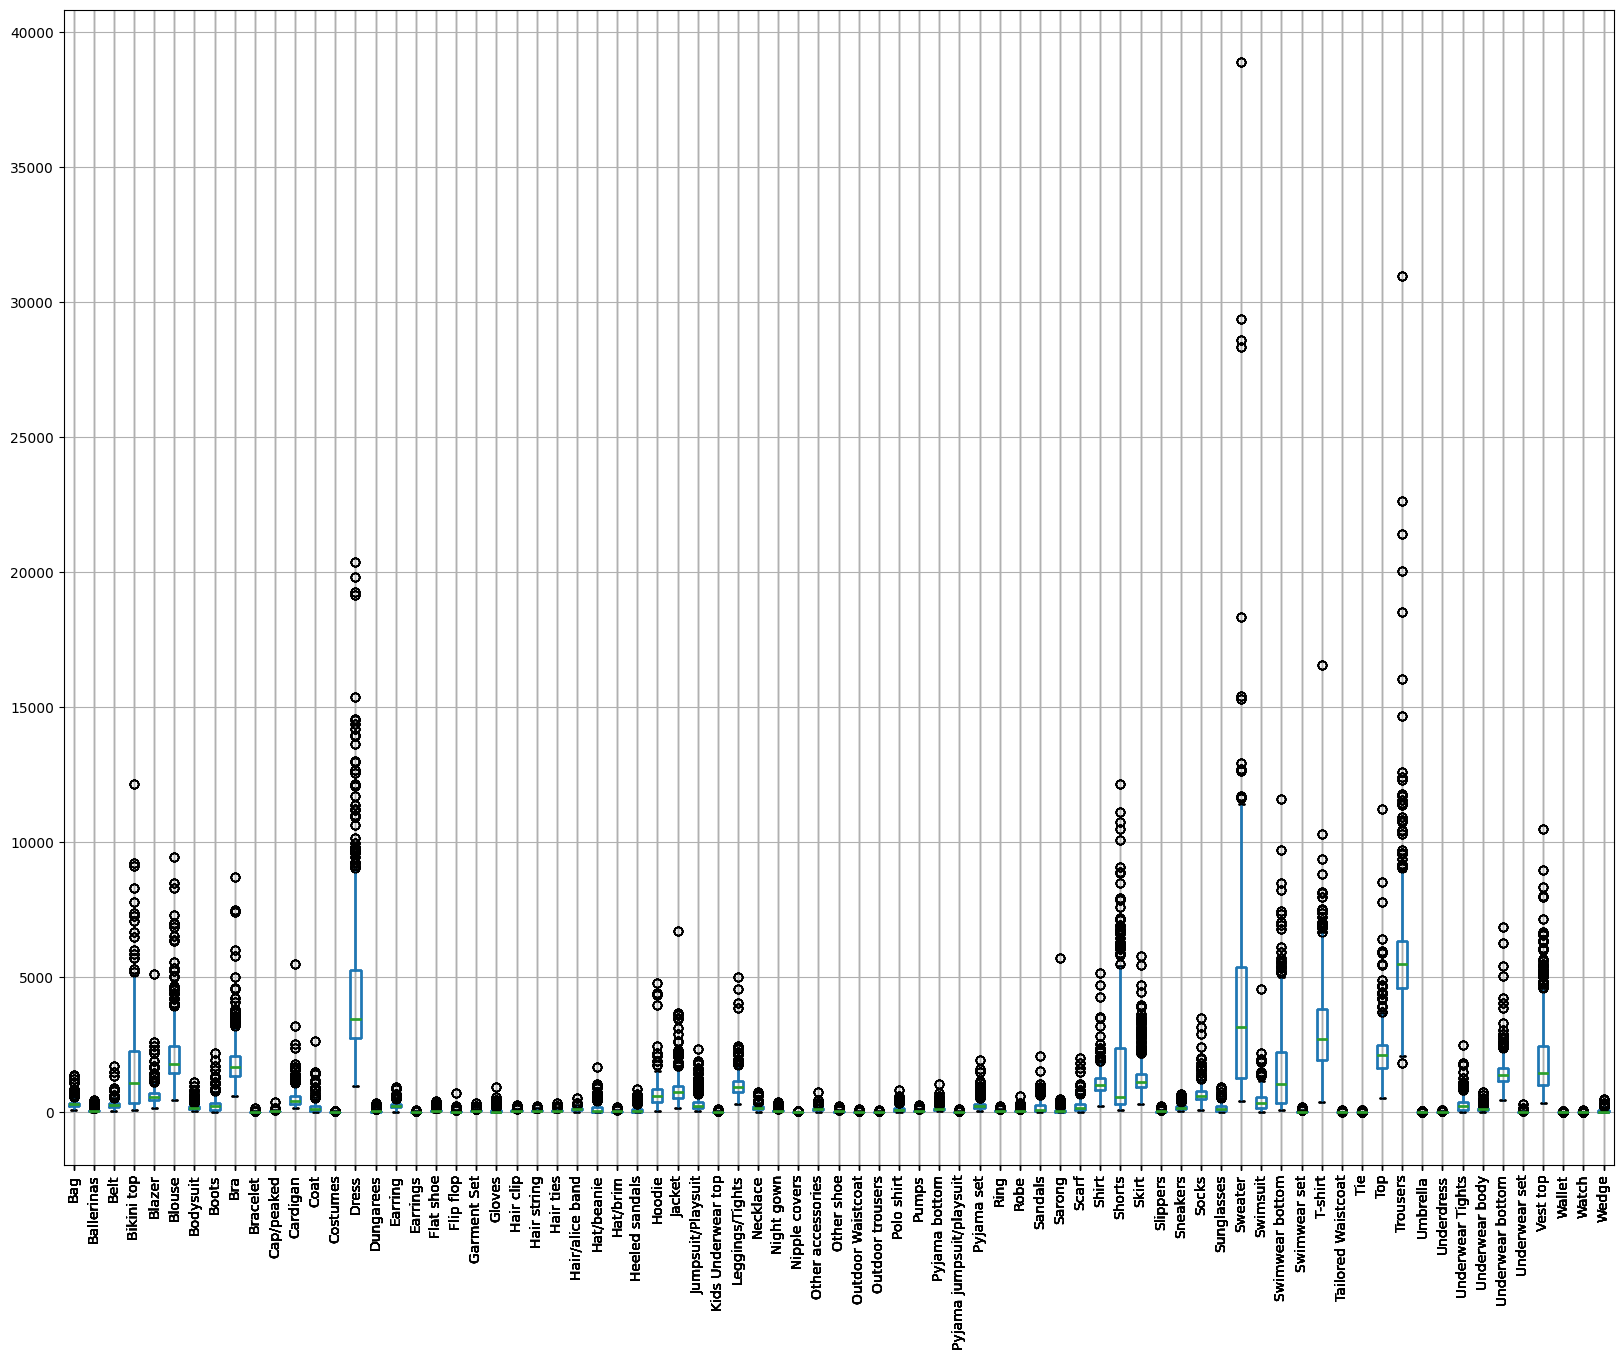

In [29]:
df_pivot.boxplot(figsize=(15,8), rot=90)
plt.show()